In [1]:
from lib.networkFuntions import get_network_details
net = 'YV'
sta = 'RR29'
cha = 'BDH.D'
dfstations = get_network_details(net, '/Volumes/SDS/INVENTORIES')
dfstations = dfstations[['net', 'sta', 'lat', 'lon', 'ele']].drop_duplicates()
dfstations.set_index('sta', inplace=True)
print(dfstations.head())



     net      lat      lon     ele
sta                               
RR01  YV -20.0069  55.4230 -4298.0
RR02  YV -20.3392  54.4984 -4436.0
RR03  YV -21.3732  54.1294 -4340.0
RR04  YV -22.2553  55.3846 -4168.0
RR05  YV -21.6626  56.6676 -4092.0


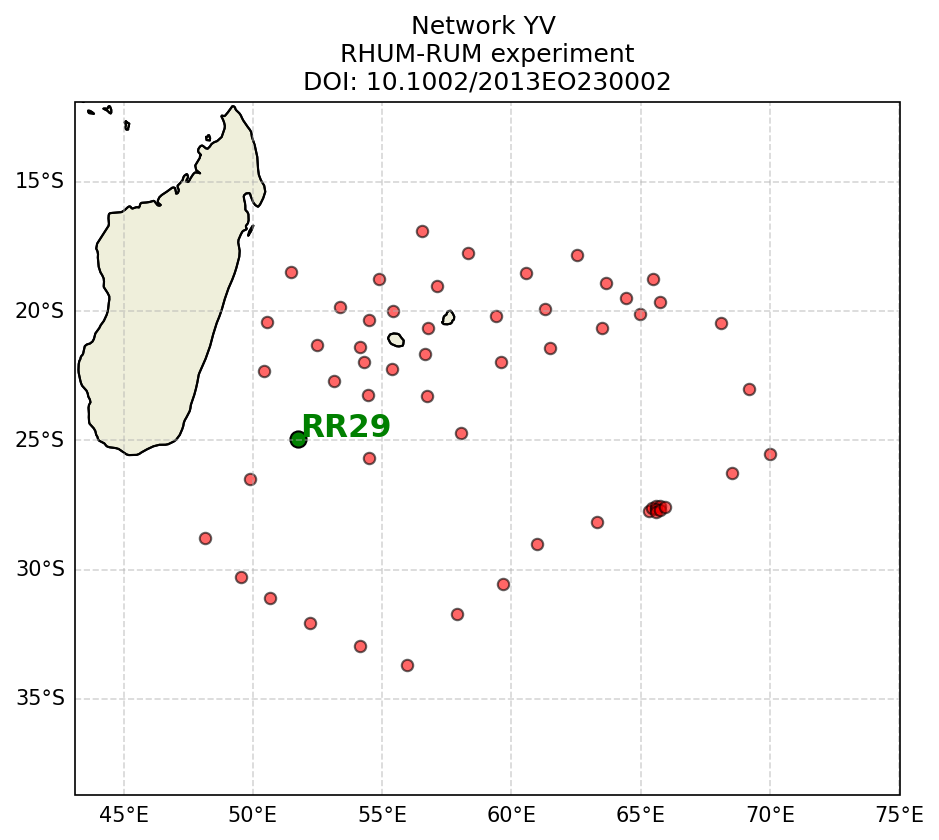

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a figure and axis with a map projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6), dpi=150)

# Add features to the map
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the stations
ax.scatter(dfstations['lon'], dfstations['lat'], color='red', edgecolor='black', s=30, alpha=0.6, label='Stations', transform=ccrs.PlateCarree())

ax.scatter(dfstations.loc[sta,'lon'], dfstations.loc[sta,'lat'], color='green', edgecolor='black', s=60, label='Stations', transform=ccrs.PlateCarree())
ax.text(dfstations.loc[sta, 'lon'] + 0.1, dfstations.loc[sta, 'lat'] + 0.1, sta, color='g', fontsize=15, fontweight='bold', transform=ccrs.PlateCarree())
# Add labels and legend
ax.set_title('Network YV \nRHUM-RUM experiment\nDOI: 10.1002/2013EO230002')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.set_extent([dfstations['lon'].min() - 5, dfstations['lon'].max() + 5, 
               dfstations['lat'].min() - 5, dfstations['lat'].max() + 5], crs=ccrs.PlateCarree())


# Add gridlines
gridlines = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gridlines.top_labels = False
gridlines.right_labels = False
# Show the plot
plt.show()